In [68]:
#importing Libraries 
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [69]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()


In [70]:
#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])


In [72]:
#filter dataframe and create a copy
df_usa =df[df['job_country']=='United States'].copy()

In [73]:
#%B months as local's full name
df_usa['job_posted_month']=df_usa['job_posted_date'].dt.strftime('%B')

In [ ]:
df_usa

In [75]:
df_usa_pivot =df_usa.pivot_table(index="job_posted_month",columns ="job_title_short",aggfunc='size')

In [ ]:
df_usa_pivot

In [77]:
df_usa_pivot.reset_index(inplace =True)

In [ ]:
df_usa_pivot

In [79]:
df_usa_pivot['month_no'] = pd.to_datetime(df_usa_pivot['job_posted_month'],format='%B').dt.month

In [ ]:
df_usa_pivot

In [81]:
df_usa_pivot.sort_values('month_no',inplace = True)

In [ ]:
df_usa_pivot

In [83]:
df_usa_pivot.set_index('job_posted_month',inplace = True)

In [84]:
df_usa_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_no
job_posted_month,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,1
February,447,24,6124,3060,4956,56,1258,878,1127,90,2
March,438,19,6218,3183,4779,59,1114,829,1150,115,3
April,565,40,6049,2801,4867,51,1025,781,991,112,4
May,279,20,4993,2976,4377,49,839,746,914,90,5
June,446,32,5683,2893,4645,48,1009,812,1033,93,6
July,581,39,5201,2570,4876,65,883,747,1095,153,7
August,903,39,6634,3269,6318,68,1186,903,1515,194,8
September,897,50,4639,3224,4568,113,805,775,1014,228,9


In [85]:
df_usa_pivot.drop(columns='month_no',inplace=True)

In [97]:
df_usa_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


<Axes: xlabel='job_posted_month'>

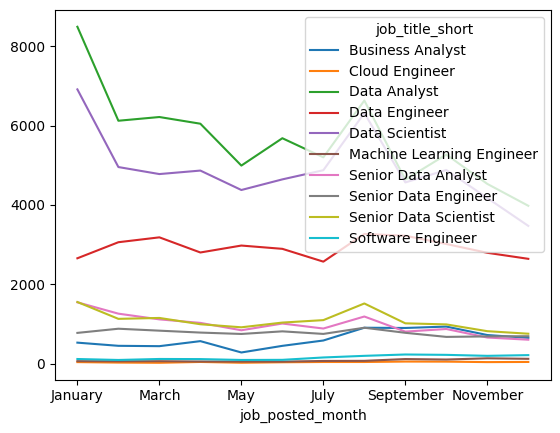

In [87]:
df_usa_pivot.plot(kind='line')

In [90]:
top_3 =df_usa['job_title_short'].value_counts().head(3)

In [91]:
top_3

job_title_short
Data Analyst      67816
Data Scientist    58830
Data Engineer     35080
Name: count, dtype: int64

In [92]:
top_3 =top_3.index.tolist()

In [94]:
top_3

['Data Analyst', 'Data Scientist', 'Data Engineer']

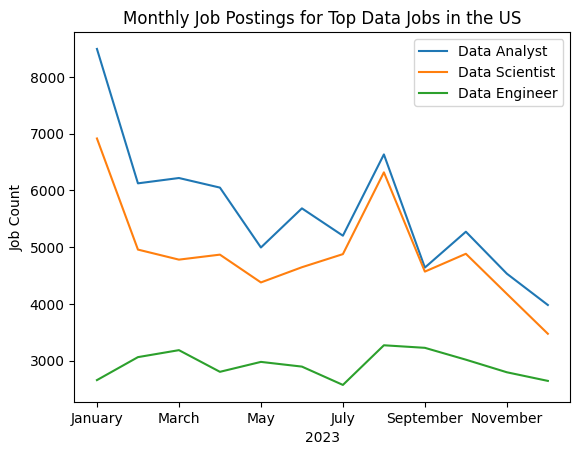

In [96]:
df_usa_pivot[top_3].plot(kind ='line')
plt.title("Monthly Job Postings for Top Data Jobs in the US")
plt.xlabel("2023")
plt.ylabel("Job Count")
plt.legend()
plt.show()